In [8]:
## Load word list

# WORDLIST_PATH = 'wordlist_len5_top5k.txt'
WORDLIST_PATH = 'wordle_list.txt'

with open(WORDLIST_PATH, 'r', encoding='utf-8') as f:
    wordlist = [line.strip() for line in f.readlines()]


print(wordlist[:10])  # Just to verify the wordlist is loaded correctly
print(f"Number of duplicates: {len(wordlist) - len(set(wordlist))}")

['budge', 'liken', 'latch', 'riser', 'puffy', 'bring', 'plume', 'crock', 'rural', 'quack']
Number of duplicates: 10


In [9]:
## Letter frequency analysis
from collections import Counter
letter_counts = Counter()
for word in wordlist:
    letter_counts.update(word)
total_letters = sum(letter_counts.values())
letter_frequencies = {letter: count / total_letters for letter, count in letter_counts.items()}
sorted_letter_frequencies: dict[str, float] = dict(sorted(letter_frequencies.items(), key=lambda item: item[1], reverse=True))
print("Letter Frequencies:")
for i, (letter, freq) in enumerate(sorted_letter_frequencies.items()):
    print(f"{i+1:2d}  {letter.upper()} {freq*100:5.2f}%")


Letter Frequencies:
 1  E 10.84%
 2  A  8.68%
 3  R  7.68%
 4  O  6.70%
 5  T  6.52%
 6  L  6.24%
 7  I  5.68%
 8  S  5.54%
 9  N  4.99%
10  C  4.09%
11  U  3.95%
12  H  3.53%
13  D  3.39%
14  Y  3.21%
15  P  2.99%
16  G  2.80%
17  M  2.75%
18  B  2.42%
19  F  2.04%
20  K  1.79%
21  W  1.61%
22  V  1.32%
23  Z  0.37%
24  X  0.36%
25  Q  0.29%
26  J  0.22%


In [10]:
## Correlation matrix for letter pairs
import numpy as np
letters = sorted(list(letter_counts.keys()))
letter_index = {letter: idx for idx, letter in enumerate(letters)}
correlation_matrix = np.zeros((len(letters), len(letters)), dtype=int)
for word in wordlist:
    unique_letters = set(word)
    for letter1 in unique_letters:
        for letter2 in unique_letters:
            if letter1 != letter2:
                i, j = letter_index[letter1], letter_index[letter2]
                correlation_matrix[i][j] += 1
correlation_matrix_float = correlation_matrix / len(wordlist)

print("\nLetter Correlation Matrix:")
print("    " + "   ".join(letters))
for i, letter1 in enumerate(letters):
    row = [f"{correlation_matrix_float[i][j]*1000:3.0f}" for j in range(len(letters))]
    print(f"{letter1} " + " ".join(row))



Letter Correlation Matrix:
    a   b   c   d   e   f   g   h   i   j   k   l   m   n   o   p   q   r   s   t   u   v   w   x   y   z
a   0  48  79  64 167  27  49  59  62   3  37 126  56  86  68  50   7 140  98 122  36  27  25   6  58   8
b  48   0  12  16  54   3  12  12  25   1   9  35  12  21  34   3   0  43  13  24  27   2   3   2  16   2
c  79  12   0  17  75  11   6  52  51   1  28  41  23  38  59  22   1  64  35  44  34   7   8   2  17   1
d  64  16  17   0  80   8  20  15  51   1   3  35  13  34  48  12   2  54  19  29  31   7  14   2  31   1
e 167  54  75  80   0  36  62  67 105   4  31 128  51  97  99  68   6 184 108 128  62  45  37  13  42   8
f  27   3  11   8  36   0   8  11  31   1   8  31   3  16  27   2   0  36  13  27  16   1   4   1  17   2
g  49  12   6  20  62   8   0  13  41   1   2  31  15  45  39   6   0  47  18  22  36   7   7   0  16   2
h  59  12  52  15  67  11  13   0  41   0  10  25  19  27  44  18   1  48  48  65  28   6  17   1  20   1
i  62  25  51  51 

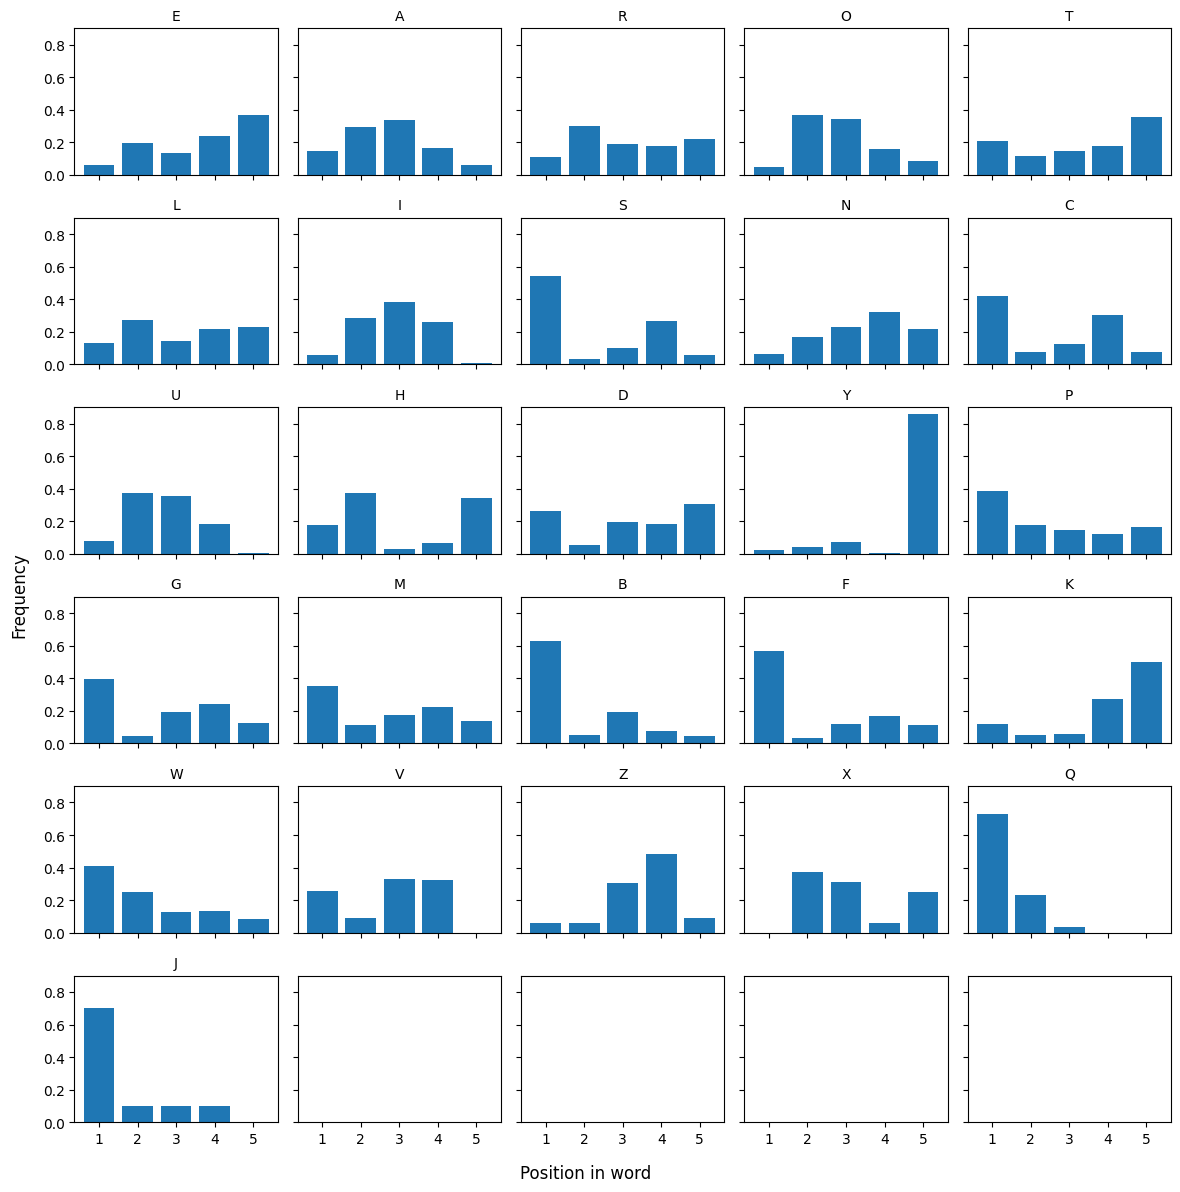

In [11]:
## letter position statistics

import numpy.typing as npt
def all_indices(s: str, sub: str) -> list[int]:
    return [i for i in range(len(s)) if s.startswith(sub, i)]

letter_indices = {char: [] for char in sorted_letter_frequencies.keys()}
n_words = {char: 0 for char in sorted_letter_frequencies.keys()}
for char in sorted_letter_frequencies.keys():
    indices = []
    for word in wordlist:
        if char in word:
            indices.extend(all_indices(word, char))
            n_words[char] += 1
    letter_indices[char] = indices
    if letter_indices[char]:
        avg_position = sum(letter_indices[char]) / len(letter_indices[char])
        # print(f"Average position of '{char}': {avg_position:.2f} over {len(letter_indices[char])} occurrences")

# Histogram
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

fig, axes = plt.subplots(6, 5, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()  # make indexing easy

for ax, char in zip(axes, sorted_letter_frequencies.keys()):
    if letter_indices[char]:
        ax.hist(
            np.array(letter_indices[char]) + 1,
            bins=range(1, 7),
            align='left',
            rwidth=0.8,
            density=True
        )
        ax.set_title(f"{char.upper()}", fontsize=10)
    else:
        ax.set_visible(False)
    ax.set_xticks(range(1, 6))

# Common labels
fig.supxlabel("Position in word")
fig.supylabel("Frequency")

# Ticks
# for ax in axes:
#     ax.set_xticks(range(1, 6))

plt.tight_layout()
plt.show()


In [12]:
from click.testing import CliRunner
from suggest import suggest

runner = CliRunner()
print(runner.invoke(suggest, ['e!123a!145rtl']).output)
print(runner.invoke(suggest, ['o!145i!15s!235nc']).output)
print(runner.invoke(suggest, ['uhdy']).output)
# suggest.callback('e!123a!145rtl')



First 1 out of 1 possibilities:
['later']



First 1 out of 1 possibilities:
['sonic']



First 1 out of 1 possibilities:
['duchy']


